# Part A : Linear Regression and Model Comparison

## Introduction

This notebook demonstrates a fundamental concept in statistics and machine learning: linear regression. We will generate a synthetic dataset, calculate a linear regression model using the least squares method, and then compare its performance against several other predefined linear models. The goal is to understand how to fit a simple linear model to data and evaluate different models based on an error metric.

## 1. Importing Necessary Libraries

We begin by importing the essential Python libraries for numerical operations, plotting, and potentially data loading (though not directly used for data loading in this specific example).

*   **`numpy`**: The cornerstone library for numerical computing in Python. It provides support for large, multi-dimensional arrays and matrices, along with a collection of high-level mathematical functions to operate on these arrays. We'll use it for data generation, array manipulation, and linear algebra operations.
*   **`matplotlib.pyplot`**: A comprehensive library for creating static, animated, and interactive visualizations in Python. We'll use its `pyplot` module for plotting our data and regression lines.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Creating the Dataset

To illustrate linear regression, we'll create a synthetic dataset that simulates a linear relationship with some random noise. This allows us to control the underlying true relationship and observe how well our models approximate it.

We aim to create a set of `x` values (independent variable) and corresponding `y` values (dependent variable) such that `y` is approximately a linear function of `x` plus some random error.

### Mathematical Concepts

The true relationship can be expressed as:

$$y = \beta_0 + \beta_1 x + \epsilon$$

where:
*   $\beta_0$ is the true intercept (here, 2).
*   $\beta_1$ is the true slope (here, 0.5).
*   $\epsilon$ represents random noise, typically assumed to be normally distributed with a mean of zero.

### Python Functions Used

*   **`np.linspace(start, stop, num)`**: Generates `num` evenly spaced samples, calculated over the interval `[start, stop]`. Here, it creates 70 values for `x` between 1 and 10.
*   **`.reshape(rows, columns)`**: Changes the shape of an array without changing its data. We reshape `x` into a column vector (70 rows, 1 column).
*   **`np.random.randn(rows, columns)`**: Returns a sample (or samples) from the 'standard normal' distribution (mean 0, variance 1). This simulates the random noise component ($\epsilon$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = np.linspace(1,10,70).reshape(70,1)
y = 2 + 0.5*x + np.random.randn(70,1)
print(y.shape)


(70, 1)


## 3. Visualizing the Observations

It's crucial to visualize the raw data to understand its distribution and potential relationships before applying any models. This helps in confirming assumptions and detecting anomalies.

We will create a scatter plot of our generated `x` and `y` values. This plot will serve as the base for all subsequent model visualizations.

### Python Functions Used

*   **`plt.scatter(x_data, y_data, label)`**: Plots individual data points as a scatter plot.
*   **`plt.set_xlabel()`, `axs[index].set_ylabel()`**: Sets the labels for the x and y axes of a subplot.
*   **`plt.set_xlim()`, `axs[index].set_ylim()`**: Sets the limits for the x and y axes, ensuring a consistent viewing window across plots.
*   **`plt.legend()`**: Displays the legend (labels specified in `scatter` or `plot` calls) for the subplot.

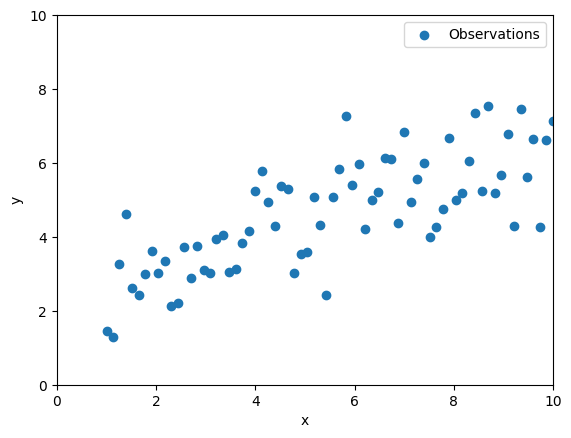

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = np.linspace(1,10,70).reshape(70,1)
y = 2 + 0.5*x + np.random.randn(70,1)

# First plot : Observations
plt.scatter(x, y, label='Observations')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim([0,10])
plt.ylim([0,10])
plt.legend()

## 4. Constructing the Regression Matrix

For linear regression using the least squares method, we often formulate the problem in a matrix form. This requires creating a 'design matrix' or 'regression matrix'.

### Objective and Logic

Our linear model is $y = \beta_0 + \beta_1 x$. To solve this using matrix operations, we can represent it as $Y = A \beta$, where $Y$ is the vector of observed `y` values, $\beta$ is the vector of coefficients ($\beta_0, \beta_1$), and $A$ is the design matrix. The design matrix needs a column of ones for the intercept term ($\beta_0$) and a column of `x` values for the slope term ($\beta_1$).

### Mathematical Concepts

Given the linear model:

$$y_i = \beta_0 \cdot 1 + \beta_1 x_i$$

For all data points, this can be written in matrix form as:

$$\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix} = \begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{pmatrix} \begin{pmatrix} \beta_0 \\ \beta_1 \end{pmatrix}$$

Here, the matrix $A$ is `a`, the vector $Y$ is `Y` (our `y` data), and the vector $\beta$ (which we want to find) is `aHat`.

### Python Functions Used

*   **`np.ones((rows, columns))`**: Creates an array of a given shape and fills it with ones. Used to create the intercept column `I`.
*   **`np.hstack((array1, array2))`**: Stacks arrays in sequence horizontally (column wise). We combine the column of ones (`I`) with our `x` values (`X`) to form the design matrix `a`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = np.linspace(1,10,70).reshape(70,1)
y = 2 + 0.5*x + np.random.randn(70,1)

X = x
Y = y
I = np.ones((70,1))
a = np.hstack((I, X))
print(f"a_{a.shape} :{a} ")


a_(70, 2) :[[ 1.          1.        ]
 [ 1.          1.13043478]
 [ 1.          1.26086957]
 [ 1.          1.39130435]
 [ 1.          1.52173913]
 [ 1.          1.65217391]
 [ 1.          1.7826087 ]
 [ 1.          1.91304348]
 [ 1.          2.04347826]
 [ 1.          2.17391304]
 [ 1.          2.30434783]
 [ 1.          2.43478261]
 [ 1.          2.56521739]
 [ 1.          2.69565217]
 [ 1.          2.82608696]
 [ 1.          2.95652174]
 [ 1.          3.08695652]
 [ 1.          3.2173913 ]
 [ 1.          3.34782609]
 [ 1.          3.47826087]
 [ 1.          3.60869565]
 [ 1.          3.73913043]
 [ 1.          3.86956522]
 [ 1.          4.        ]
 [ 1.          4.13043478]
 [ 1.          4.26086957]
 [ 1.          4.39130435]
 [ 1.          4.52173913]
 [ 1.          4.65217391]
 [ 1.          4.7826087 ]
 [ 1.          4.91304348]
 [ 1.          5.04347826]
 [ 1.          5.17391304]
 [ 1.          5.30434783]
 [ 1.          5.43478261]
 [ 1.          5.56521739]
 [ 1.          5.

## 5. Computing the Least Squares Solution

With our design matrix constructed, we can now compute the coefficients that define the best-fit line using the least squares method.


The least squares method finds the coefficients ($\beta_0, \beta_1$) that minimize the sum of the squared differences between the observed `y` values and the `y` values predicted by the linear model. This is a common way to fit linear models.

### Mathematical Concepts

The solution to the linear least squares problem, in matrix form, is given by:

$$\hat{\beta} = (A^T A)^{-1} A^T Y$$

Where:
*   $\hat{\beta}$ (`aHat`) is the vector of estimated coefficients (intercept and slope).
*   $A$ (`a`) is the design matrix.
*   $A^T$ is the transpose of the design matrix.
*   $(A^T A)^{-1}$ is the inverse of the matrix product $A^T A$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = np.linspace(1,10,70).reshape(70,1)
y = 2 + 0.5*x + np.random.randn(70,1)

X = x
Y = y
I = np.ones((70,1))
A = np.hstack((I, X))


# Least Squares Solution
AT = A.T

ATA = AT @ A
ATA_inv = np.linalg.inv(ATA)

ATY = AT @ y

aHat = ATA_inv @ ATY

a0 = aHat[0,0]
a1 = aHat[1,0]

print("aHat = ")
print(aHat)

aHat = 
[[1.87244538]
 [0.50722894]]


## 6. Plotting the Regression Line (Model 1)

Now that we have computed the coefficients for our first linear model, we can plot this line alongside our original observations to visually assess its fit.


We will add the line representing Model 1 (calculated using least squares) to the second subplot (`axs[1]`). This allows for a clear visual comparison between the raw data and the fitted model.

### Python Functions Used

*   **`np.arange(start, stop)`**: Returns evenly spaced values within a given interval. Here, `np.arange(1,11)` creates values from 1 up to (but not including) 11, which serves as the x-range for plotting our regression line.
*   **`axs[index].plot(x_data, y_data, format_string, label)`**: Plots lines on the specified subplot. The `format_string` `'-k'` indicates a solid black line. We use `Y1 = a0 + a1*X1` to generate the predicted `y` values for our plotting range.

aHat = 
[[2.1000471 ]
 [0.50661411]]


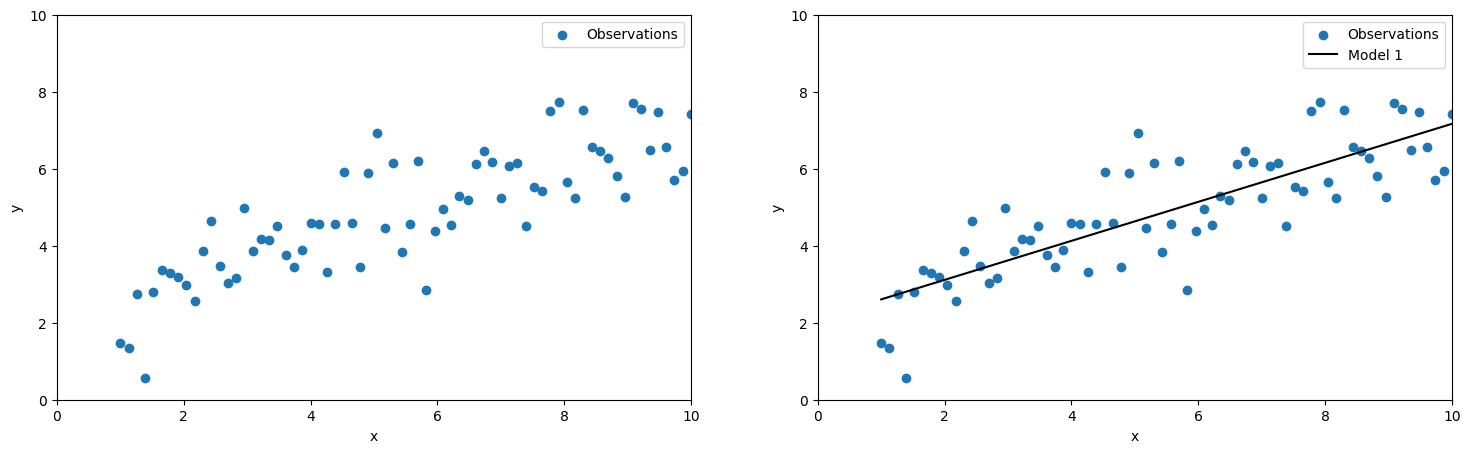

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = np.linspace(1,10,70).reshape(70,1)
y = 2 + 0.5*x + np.random.randn(70,1)

fig, axs = plt.subplots(1,2, figsize=(18,5))


axs[0].scatter(x, y, label='Observations')

axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

axs[0].set_xlim([0,10])
axs[0].set_ylim([0,10])

axs[0].legend()


X = x
Y = y
I = np.ones((70,1))
A = np.hstack((I, X))


# Least Squares Solution
AT = A.T

ATA = AT @ A
ATA_inv = np.linalg.inv(ATA)

ATY = AT @ y

aHat = ATA_inv @ ATY
a0 = aHat[0,0]
a1 = aHat[1,0]

print("aHat = ")
print(aHat)

axs[1].scatter(x, y, label='Observations')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_xlim([0,10])
axs[1].set_ylim([0,10])

X1 = np.arange(1,11)
Y1 = a0 + a1*X1

axs[1].plot(X1, Y1, '-k', label='Model 1')
axs[1].legend()

## 7. Comparing Different Regression Models

To further understand the concept of model fit, we will plot several different linear models on the same graph, including our calculated least squares model and three other predefined models.

In the third subplot (`axs[2]`), we'll display the original observations along with four different linear models. Model 1 is our least squares solution. Models 2, 3, and 4 are defined with arbitrary coefficients to show how different slopes and intercepts visually affect the fit to the data.

### Python Functions Used

*   **`np.array([[value1], [value2]])`**: Creates a 2x1 NumPy array, representing the `aHat` (coefficients) for the predefined models.
*   **`axs[index].plot(x_data, y_data, format_string, label)`**: Used repeatedly with different `format_string` values (`'-r'`, `'-b'`, `'-g'`) to plot Model 2 (red), Model 3 (blue), and Model 4 (green), respectively.
*   **`axs[index].legend(loc='upper left')`**: Places the legend in the upper-left corner of the subplot for clarity.
*   **`plt.tight_layout()`**: Automatically adjusts subplot parameters for a tight layout.
*   **`plt.show()`**: Displays the generated figure with all subplots.

aHat = 
[[1.92065917]
 [0.50531937]]


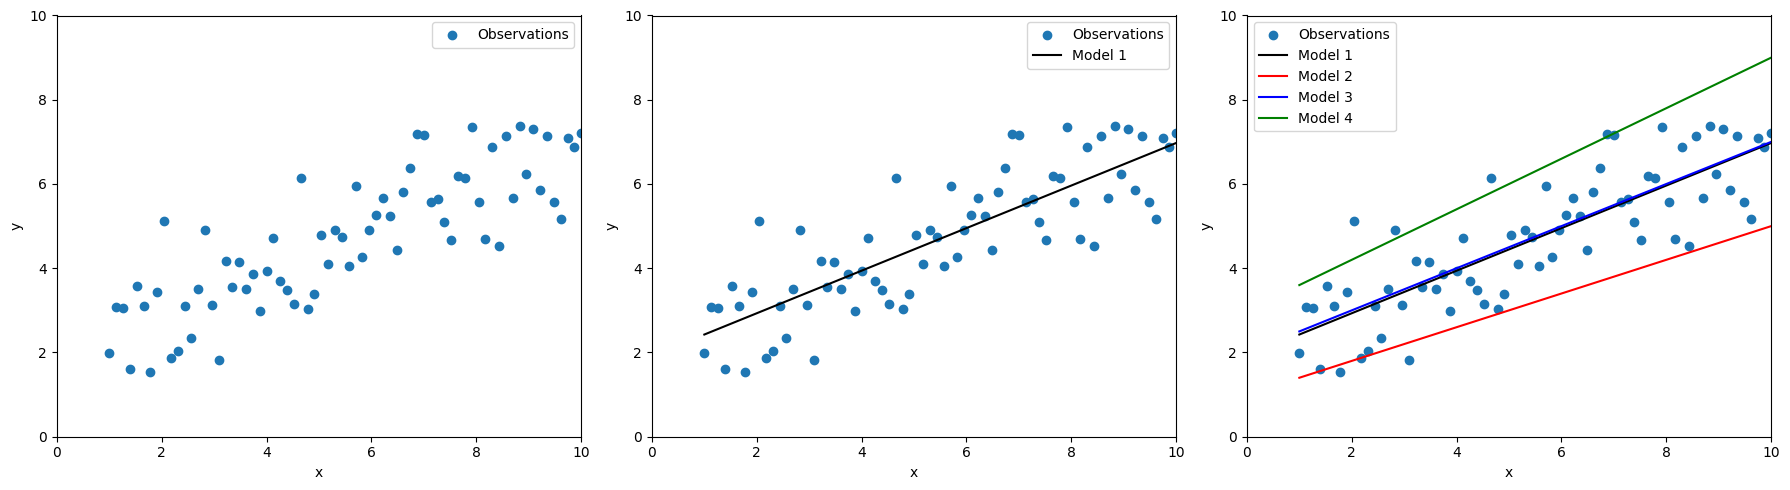

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = np.linspace(1,10,70).reshape(70,1)
y = 2 + 0.5*x + np.random.randn(70,1)

fig, axs = plt.subplots(1,3, figsize=(18,5))


axs[0].scatter(x, y, label='Observations')

axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

axs[0].set_xlim([0,10])
axs[0].set_ylim([0,10])

axs[0].legend()


X = x
Y = y
I = np.ones((70,1))
A = np.hstack((I, X))


# Least Squares Solution
AT = A.T

ATA = AT @ A
ATA_inv = np.linalg.inv(ATA)

ATY = AT @ y

aHat = ATA_inv @ ATY
a0 = aHat[0,0]
a1 = aHat[1,0]

print("aHat = ")
print(aHat)

axs[1].scatter(x, y, label='Observations')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_xlim([0,10])
axs[1].set_ylim([0,10])

X1 = np.arange(1,11)
Y1 = a0 + a1*X1

axs[1].plot(X1, Y1, '-k', label='Model 1')
axs[1].legend()


axs[2].scatter(x, y, label='Observations')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')
axs[2].set_xlim([0,10])
axs[2].set_ylim([0,10])

# Model 1
X1 = np.arange(1,11)
Y1 = a0 + a1*X1
axs[2].plot(X1, Y1, '-k', label='Model 1')

# Model 2
X2 = np.arange(1,11)
aHat2 = np.array([["1"],
                  ["0.4"]], dtype=float)
a0_2 = aHat2[0,0]
a1_2 = aHat2[1,0]
Y2 = a0_2 + a1_2*X2
axs[2].plot(X2, Y2, '-r', label='Model 2')

# Model 3
X3 = np.arange(1,11)
aHat3 = np.array([["2"],
                  ["0.5"]], dtype=float)
a0_3 = aHat3[0,0]
a1_3 = aHat3[1,0]
Y3 = a0_3 + a1_3*X3
axs[2].plot(X3, Y3, '-b', label='Model 3')

# Model 4
X4 = np.arange(1,11)
aHat4 = np.array([["3"],
                  ["0.6"]], dtype=float)
a0_4 = aHat4[0,0]
a1_4 = aHat4[1,0]
Y4 = a0_4 + a1_4*X4
axs[2].plot(X4, Y4, '-g', label='Model 4')

axs[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 8. Error Metric and Best Fit Model

Visual inspection can give a good intuition, but to quantitatively compare models, we need a numerical error metric. The sum of squared errors (SSE) is a common choice for regression problems.

### Objective and Logic

We will calculate the SSE for each of the four models. The model with the lowest SSE is considered the 'best-fit' model according to this metric.

### Mathematical Concepts

The Sum of Squared Errors (SSE) for a linear model is defined as:

$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Where:
*   $y_i$ is the actual observed value.
*   $\hat{y}_i$ is the predicted value from the model for the $i$-th observation, i.e., $\hat{y}_i = \beta_0 + \beta_1 x_i$.

The least squares method, by definition, finds the coefficients that minimize this SSE.

### Python Functions Used

*   **`np.sum((actual_y - predicted_y)**2)`**: Calculates the sum of the squared differences between actual and predicted values for each model.
*   **`errors = [S1, S2, S3, S4]`**: Creates a list of the calculated SSE values.
*   **`np.argmin(list)`**: Returns the index of the minimum value in a list or array. We add 1 to this index because array indices are 0-based, but our model numbers start from 1.

(70, 2)
aHat = 
[[2.02739242]
 [0.4718998 ]]


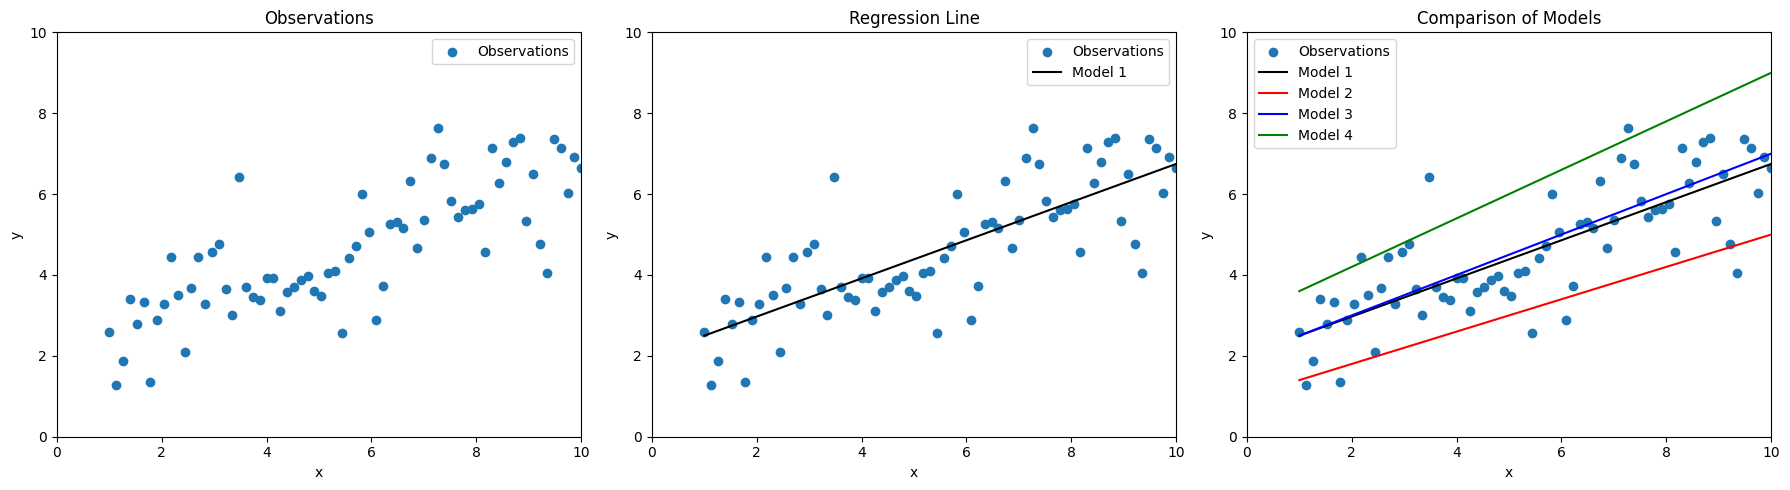

Metric value for line 1: 63.35970661783896
Metric value for line 2: 207.58654981486026
Metric value for line 3: 64.87547059008816
Metric value for line 4: 268.2383044087943
The best-fit line will be line 1


In [ ]:
# ==========================================================
# Import Necessary Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


# ==========================================================
# Create Dataset
# ==========================================================

x = np.linspace(1,10,70).reshape(70,1)

y = 2 + 0.5*x + np.random.randn(70,1)


# ==========================================================
# Create Subplots
# ==========================================================

fig, axs = plt.subplots(1,3, figsize=(18,5))


# ==========================================================
# Visualize Observations
# ==========================================================

axs[0].scatter(x, y, label='Observations')

axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

axs[0].set_xlim([0,10])
axs[0].set_ylim([0,10])

axs[0].set_title('Observations')

axs[0].legend()


# ==========================================================
# Construct Regression Matrix
# ==========================================================

X = x
Y = y

I = np.ones((70,1))

A = np.hstack((I, X))


# ==========================================================
# Compute Least Squares Solution
# ==========================================================
AT = A.T

ATA = AT @ A
ATA_inv = np.linalg.inv(ATA)

ATY = AT @ y

aHat = ATA_inv @ ATY

a0 = aHat[0,0]
a1 = aHat[1,0]

print("aHat = ")
print(aHat)


# ==========================================================
# Plot Regression Line
# ==========================================================

axs[1].scatter(x, y, label='Observations')

axs[1].set_xlabel('x')
axs[1].set_ylabel('y')

axs[1].set_xlim([0,10])
axs[1].set_ylim([0,10])

X1 = np.arange(1,11)

Y1 = a0 + a1*X1

axs[1].plot(X1, Y1, '-k', label='Model 1')

axs[1].set_title('Regression Line')

axs[1].legend()


# ==========================================================
# Compare Different Regression Models
# ==========================================================

axs[2].scatter(x, y, label='Observations')

axs[2].set_xlabel('x')
axs[2].set_ylabel('y')

axs[2].set_xlim([0,10])
axs[2].set_ylim([0,10])


# ----------------------------------------------------------
# Model 1
# ----------------------------------------------------------

X1 = np.arange(1,11)

Y1 = a0 + a1*X1

axs[2].plot(X1, Y1, '-k', label='Model 1')


# ----------------------------------------------------------
# Model 2
# ----------------------------------------------------------

X2 = np.arange(1,11)

aHat2 = np.array([[1],
                  [0.4]])

a0_2 = aHat2[0,0]
a1_2 = aHat2[1,0]

Y2 = a0_2 + a1_2*X2

axs[2].plot(X2, Y2, '-r', label='Model 2')


# ----------------------------------------------------------
# Model 3
# ----------------------------------------------------------

X3 = np.arange(1,11)

aHat3 = np.array([[2],
                  [0.5]])

a0_3 = aHat3[0,0]
a1_3 = aHat3[1,0]

Y3 = a0_3 + a1_3*X3

axs[2].plot(X3, Y3, '-b', label='Model 3')


# ----------------------------------------------------------
# Model 4
# ----------------------------------------------------------

X4 = np.arange(1,11)

aHat4 = np.array([[3],
                  [0.6]])

a0_4 = aHat4[0,0]
a1_4 = aHat4[1,0]

Y4 = a0_4 + a1_4*X4

axs[2].plot(X4, Y4, '-g', label='Model 4')

axs[2].set_title('Comparison of Models')

axs[2].legend(loc='upper left')


# ==========================================================
# Adjust Layout
# ==========================================================

plt.tight_layout()

plt.show()


# ==========================================================
# Compute Error Metric
# ==========================================================

S1 = np.sum((Y - (a0 + a1*X))**2)

print("Metric value for line 1:", S1)


S2 = np.sum((Y - (a0_2 + a1_2*X))**2)

print("Metric value for line 2:", S2)


S3 = np.sum((Y - (a0_3 + a1_3*X))**2)

print("Metric value for line 3:", S3)


S4 = np.sum((Y - (a0_4 + a1_4*X))**2)

print("Metric value for line 4:", S4)


# ==========================================================
# Best Fit Model
# ==========================================================

errors = [S1, S2, S3, S4]

bestModel = np.argmin(errors) + 1

print("The best-fit line will be line", bestModel)

## Practice Question

Consider the following observations:

\[
(1,2), (2,3), (3,5), (4,4), (5,6)
\]

In this practice exercise, we applied linear regression to the given set of observed data points.

The notebook demonstrated the following steps:

1. **Constructing the regression model** using the given observations.
2. **Computing the best-fit parameters** for the linear equation.
3. **Plotting the observations and regression line** to visualize how well the model represents the data.
4. **Calculating the Mean Squared Error (MSE)** to measure the prediction error of the regression model.

From the obtained regression line, we observe that the model captures the general trend of the dataset. The Mean Squared Error provides a numerical indication of the fitting accuracy, where smaller values indicate a better fit.

This exercise illustrates the fundamental principle of linear regression: determining the line that best approximates the observed data by minimizing the overall squared error.

aHat = 
[[1.3]
 [0.9]]


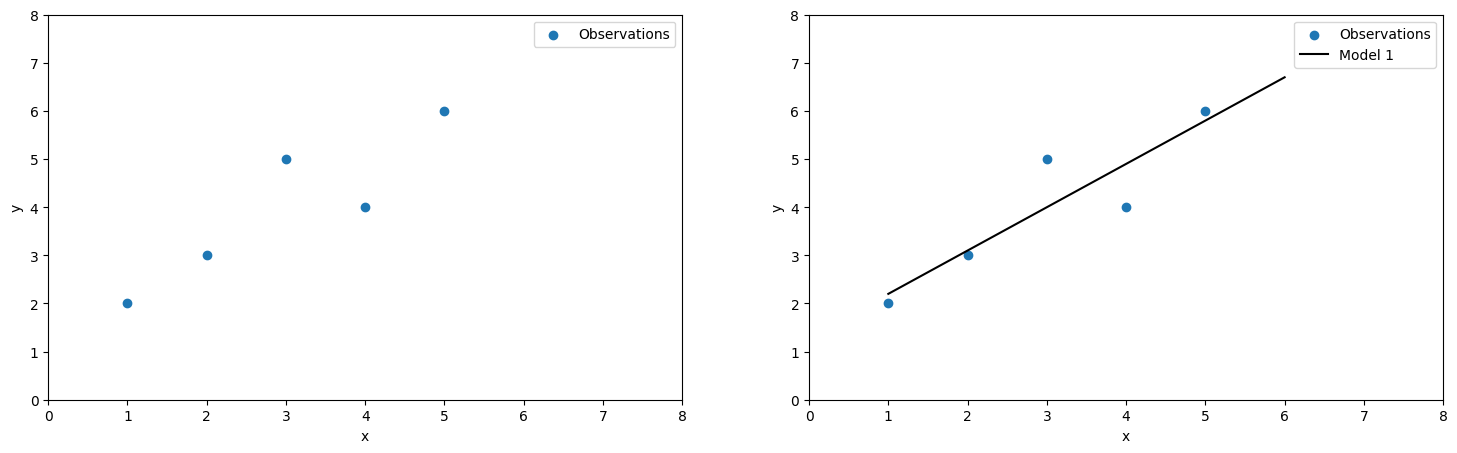

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Create data
x = np.array([[1], [2], [3], [4], [5]])
y = np.array([[2], [3], [5], [4], [6]])

fig, axs = plt.subplots(1,2, figsize=(18,5))


axs[0].scatter(x, y, label='Observations')

axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

axs[0].set_xlim([0,8])
axs[0].set_ylim([0,8])

axs[0].legend()


X = x
Y = y
I = np.ones((X.shape[0],1))
A = np.hstack((I, X))

# Least Squares Solution
AT = A.T

ATA = AT @ A
ATA_inv = np.linalg.inv(ATA)

ATY = AT @ y

aHat = ATA_inv @ ATY
a0 = aHat[0,0]
a1 = aHat[1,0]

print("aHat = ")
print(aHat)

axs[1].scatter(x, y, label='Observations')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_xlim([0,8])
axs[1].set_ylim([0,8])

X1 = np.arange(1,7)
Y1 = a0 + a1*X1

axs[1].plot(X1, Y1, '-k', label='Model 1')
axs[1].legend()

## Conclusion
In this notebook, we implemented linear regression using least squares estimation on a synthetically generated dataset. We visualized the observations, computed the best-fit regression line, and compared different regression models using the Sum of Squared Errors (SSE).

This exercise demonstrated how linear regression can model relationships between variables and determine the line that best fits the observed data.

# Part B: Image Compression using Singular Value Decomposition (SVD)

This section of the notebook explores image compression techniques using Singular Value Decomposition (SVD). We will load an image, separate it into its Red, Green, and Blue (RGB) color channels, and then apply SVD to each channel to perform rank approximation. By using a reduced number of singular values, we can reconstruct a compressed version of the image, demonstrating the power of SVD in dimensionality reduction while preserving significant image information.

## 1. Introduction to SVD and Image Compression

Image compression is a critical technology for efficient storage and transmission of digital images. Singular Value Decomposition (SVD) is a powerful matrix factorization technique from linear algebra that provides an elegant solution for this problem. SVD allows us to decompose an image (represented as a matrix) into a set of singular values and vectors. By retaining only the most significant singular values and their corresponding vectors, we can reconstruct an approximation of the original image with reduced data, thus achieving compression.

The core idea is that most of the 'information' or 'energy' in an image is concentrated in a few large singular values. By discarding the smaller singular values, which often correspond to noise or fine details less crucial for perception, we can significantly reduce the amount of data needed to represent the image while maintaining a recognizable quality.

## 2. Importing Necessary Libraries

We begin by importing the essential Python libraries for numerical operations, image processing, and plotting. Additionally, we mount Google Drive to access image files stored there.
### Python Functions Used
*   **`PIL.Image`**: The Python Imaging Library (Pillow) is used for opening, manipulating, and saving many different image file formats.
*   **`google.colab.drive.mount('/content/drive')`**: This function from `google.colab` is used to mount your Google Drive to the Colab environment, allowing you to access files stored in your Drive.
*   **`drive.mount('/content/drive')`**: Mounts Google Drive, making files accessible at `/content/drive`.
*   **`Image.open('/path/to/image.jpg')`**: Opens an image file from the specified path. It returns a PIL Image object.
*   **`np.array(image_object)`**: Converts a PIL Image object into a NumPy array. This is essential because `numpy` arrays allow for efficient mathematical operations on image data (e.g., slicing, SVD).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

SourceImg = cv2.imread('Lab2_Img.png')
SourceImg = np.array(SourceImg)

## 3. Splitting RGB Channels

An RGB image is a three-dimensional NumPy array where the first two dimensions represent the height and width, and the third dimension (usually of size 3) represents the color channels (Red, Green, Blue). By slicing the array along the third dimension, we can extract each channel as a 2D array. For example, `SourceImg[:,:,0]` extracts all rows and columns for the first channel (Red).

### Python Functions Used
*   **`SourceImg[:,:,0]`**: Extracts the Red channel (first channel, index 0) from the `SourceImg` NumPy array. The `:` indicates selecting all elements along that dimension.
*   **`SourceImg[:,:,1]`**: Extracts the Green channel (second channel, index 1).
*   **`SourceImg[:,:,2]`**: Extracts the Blue channel (third channel, index 2).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

SourceImg = cv2.imread('Lab2_Img.png')
SourceImg = np.array(SourceImg)

# ----------------------------------------------------------
# Red Channel
# ----------------------------------------------------------
sourceImgRed = SourceImg[:,:,0]

# ----------------------------------------------------------
# Green Channel
# ----------------------------------------------------------
sourceImgGreen = SourceImg[:,:,1]

# ----------------------------------------------------------
# Blue Channel
# ----------------------------------------------------------
sourceImgBlue = SourceImg[:,:,2]

## 4. Visualizing the Original Image and Color Channels

Visualizing the original image and its individual RGB channels helps us understand how colors are composed and provides a baseline for comparison with compressed images later. Each channel, when viewed individually, appears as a grayscale image where the intensity represents the contribution of that specific color.

### Python Functions Used
*   **`axs[index].imshow(image_data, cmap)`**: Displays an image on a specific subplot. For individual color channels, `cmap` (colormap) is used to display them with appropriate colors (e.g., 'Reds', 'Greens', 'Blues'). For the original image, `imshow` automatically handles the RGB array.
*   **`axs[index].axis('off')`**: Turns off the axis labels and ticks for a cleaner image display.
*   **`plt.tight_layout()`**: Adjusts subplot parameters for a tight layout, preventing labels from overlapping.


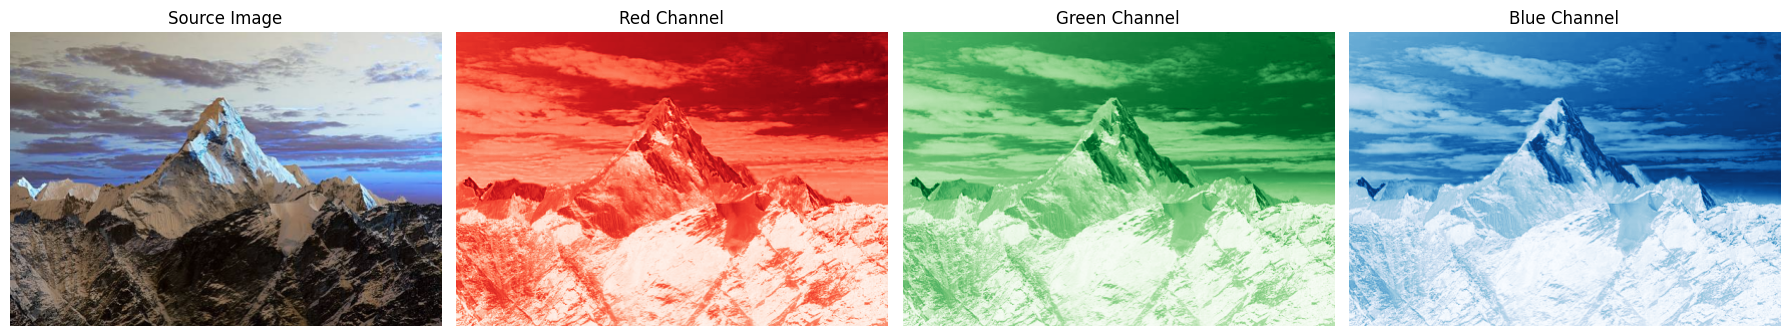

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

SourceImg = cv2.imread('Lab2_Img.png')
SourceImg = np.array(SourceImg)

# ----------------------------------------------------------
# Red Channel
# ----------------------------------------------------------
sourceImgRed = SourceImg[:,:,0]

# ----------------------------------------------------------
# Green Channel
# ----------------------------------------------------------
sourceImgGreen = SourceImg[:,:,1]

# ----------------------------------------------------------
# Blue Channel
# ----------------------------------------------------------
sourceImgBlue = SourceImg[:,:,2]

fig, axs = plt.subplots(1,4, figsize=(18,5))

# ----------------------------------------------------------
# Source Image plot
# ----------------------------------------------------------
axs[0].imshow(SourceImg)
axs[0].set_title("Source Image")
axs[0].axis('off')

# ----------------------------------------------------------
# Red Channel plot
# ----------------------------------------------------------
axs[1].imshow(sourceImgRed, cmap='Reds')
axs[1].set_title("Red Channel")
axs[1].axis('off')

# ----------------------------------------------------------
# Green Channel plot
# ----------------------------------------------------------
axs[2].imshow(sourceImgGreen, cmap='Greens')
axs[2].set_title("Green Channel")
axs[2].axis('off')

# ----------------------------------------------------------
# Blue Channel plot
# ----------------------------------------------------------
axs[3].imshow(sourceImgBlue, cmap='Blues')
axs[3].set_title("Blue Channel")
axs[3].axis('off')

plt.tight_layout()
plt.show()

## 5. Understanding Singular Value Decomposition (SVD)

Singular Value Decomposition (SVD) is a fundamental matrix factorization technique with numerous applications, including dimensionality reduction, noise reduction, and data compression. For an image, which can be represented as a matrix, SVD allows us to break down the image into a set of components that capture different aspects of its information content.

### Mathematical Concepts

SVD decomposes a matrix `M` (e.g., a single color channel of an image) into three other matrices:

$$M = U \Sigma V^T$$

Where:
*   **`M`**: The original matrix (e.g., `sourceImgRed`), with dimensions $m \times n$.
*   **`U`**: An $m \times m$ orthogonal matrix whose columns are the left singular vectors of `M`. These vectors represent the column space of `M`.
*   **`Σ` (Sigma)**: An $m \times n$ diagonal matrix containing the singular values of `M`. The singular values ($\sigma_1, \sigma_2, ..., \sigma_k$) are non-negative and are conventionally arranged in descending order along the diagonal. These values indicate the 'importance' or 'energy' associated with each singular vector pair. The number of non-zero singular values equals the rank of the matrix.
*   **`V^T`**: The transpose of an $n \times n$ orthogonal matrix `V`, whose rows (columns of `V`) are the right singular vectors of `M`. These vectors represent the row space of `M`.

In the context of image processing, `U` and `V` contain basis vectors, and `Σ` contains coefficients (singular values) that scale these basis vectors. By keeping only the largest singular values and their corresponding vectors, we can reconstruct a lower-rank approximation of the original image.

## 6. Computing SVD for RGB Channels

To apply SVD-based compression, we need to perform SVD on each of the individual RGB color channels. Each channel is treated as a grayscale image (a 2D matrix), and the SVD process is applied to it independently.

For each color channel (Red, Green, Blue), we use `np.linalg.svd` to compute its singular value decomposition. The `astype(float)` conversion is important because SVD functions typically operate on floating-point numbers.

### Python Functions Used
*   **`np.linalg.svd(matrix.astype(float), full_matrices=False)`**: This is the core function for computing SVD. It takes a matrix (e.g., `sourceImgRed`) as input, converts its elements to float for precision, and returns three arrays:
    *   `U`: The left singular vectors.
    *   `S`: The singular values.
    *   `V`: The right singular vectors

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

SourceImg = cv2.imread('Lab2_Img.png')
SourceImg = np.array(SourceImg)

# ----------------------------------------------------------
# Red Channel
# ----------------------------------------------------------
sourceImgRed = SourceImg[:,:,0]

# ----------------------------------------------------------
# Green Channel
# ----------------------------------------------------------
sourceImgGreen = SourceImg[:,:,1]

# ----------------------------------------------------------
# Blue Channel
# ----------------------------------------------------------
sourceImgBlue = SourceImg[:,:,2]

# SVD for Red Channel
Ur, Sr, Vr = np.linalg.svd(sourceImgRed.astype(float))


# SVD for Green Channel
Ug, Sg, Vg = np.linalg.svd(sourceImgGreen.astype(float))


# SVD for Blue Channel
Ub, Sb, Vb = np.linalg.svd(sourceImgBlue.astype(float))


## 7. Constructing Rank Approximations

The power of SVD for compression lies in its ability to approximate the original matrix using only a subset of its singular values. This is known as rank approximation, where we construct a lower-rank matrix that is a good approximation of the original.

### Objective and Logic

Given the SVD decomposition $M = U \Sigma V^T$, we can approximate `M` by taking only the first `k` singular values and their corresponding singular vectors. The formula for a rank-`k` approximation ($M_k$) is:

$$M_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

where:
*   $\sigma_i$ is the $i$-th singular value from `S`.
*   $\mathbf{u}_i$ is the $i$-th column of `U` (the $i$-th left singular vector).
*   $\mathbf{v}_i^T$ is the $i$-th row of `V^T` (the $i$-th right singular vector).

In our code, we iterate `k` times, summing the outer products of the corresponding singular vectors, scaled by their singular values. This process is applied to each RGB channel independently to produce three approximated channels.

We choose different values for `k` (e.g., `N/2`, `N/20`, `N/200`, where `N` is the image width) to demonstrate varying levels of compression and their impact on image quality. A smaller `k` means higher compression but potentially lower quality.

### Python Functions Used
*   **`N = SourceImg.shape[1]`**: Retrieves the width of the image. This value is used to determine the `k` values for approximation (e.g., `N//2`, `N//20`, `N//200`).
*   **`Ur[:,i:i+1]`**: Selects the $i$-th left singular vector (as a column vector) from `U`.
*   **`np.array([[Sr[i]]])`**: Creates a 1x1 matrix from the $i$-th singular value. This is used to correctly perform matrix multiplication.
*   **`Vr[i:i+1,:]`**: Selects the $i$-th right singular vector (as a row vector) from `V^T`.
*   **`k1 = k1 + (Ur[:,i:i+1] @ np.array([[Sr[i]]]) @ Vr[i:i+1,:])`**: This line performs the core rank approximation. The `@` operator is used for matrix multiplication. It accumulates the sum of the outer products for each singular value up to `k`.

## 8. Reconstructing Compressed Images

After performing rank approximation on each of the Red, Green, and Blue channels, the final step is to combine these approximated channels back into a single color image. This reconstructed image will be a compressed version of the original, with its quality depending on the number of singular values (`k`) used in the approximation.

### Objective and Logic

The three approximated 2D matrices (one for each color channel) are stacked along the third dimension to form a new 3D array, which represents the reconstructed RGB image. Since image pixel values typically range from 0 to 255 and SVD operations can produce floating-point numbers outside this range, it's crucial to clip these values and convert the data type to unsigned 8-bit integers (`uint8`).

### Python Functions Used
*   **`np.dstack((k1,k2,k3))`**: Stacks the approximated Red (`k1`), Green (`k2`), and Blue (`k3`) channels along the third axis to form a new RGB image. This creates a 3D NumPy array suitable for image display.
*   **`np.clip(array, min_val, max_val)`**: Clips array values to be within a specified range. For 8-bit images, pixel values must be between 0 and 255. This function ensures that any values outside this range are brought within it.
*   **`np.uint8(array)`**: Converts the array to an 8-bit unsigned integer type. This is the standard data type for pixel values in most image formats, ensuring proper display and compatibility.
###  Comparing Different Rank Approximations

Finally, we display the original image alongside the images reconstructed with different levels of SVD approximation. This visual comparison allows us to intuitively understand the trade-off between compression ratio and perceived image quality. As the number of singular values (`k`) decreases, the image becomes more compressed but loses detail and may show artifacts.

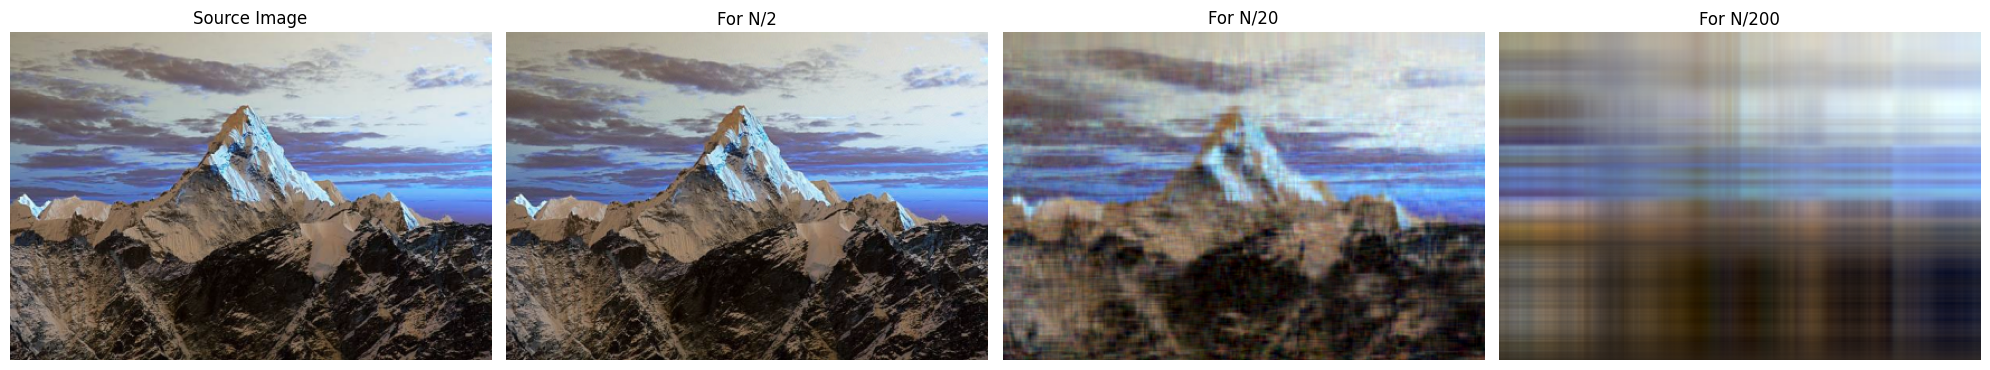

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

SourceImg = cv2.imread('Lab2_Img.png')
SourceImg = np.array(SourceImg)

# ----------------------------------------------------------
# Red Channel
# ----------------------------------------------------------
sourceImgRed = SourceImg[:,:,0]

# ----------------------------------------------------------
# Green Channel
# ----------------------------------------------------------
sourceImgGreen = SourceImg[:,:,1]

# ----------------------------------------------------------
# Blue Channel
# ----------------------------------------------------------
sourceImgBlue = SourceImg[:,:,2]

# SVD for Red Channel
Ur, Sr, Vr = np.linalg.svd(sourceImgRed.astype(float))


# SVD for Green Channel
Ug, Sg, Vg = np.linalg.svd(sourceImgGreen.astype(float))


# SVD for Blue Channel
Ub, Sb, Vb = np.linalg.svd(sourceImgBlue.astype(float))


fig, axs = plt.subplots(1,4, figsize=(20,5))

# ----------------------------------------------------------
# Source Image
# ----------------------------------------------------------
axs[0].imshow(SourceImg)
axs[0].set_title("Source Image")
axs[0].axis('off')


# ==========================================================
# N/2 Approximation
# ==========================================================

N = SourceImg.shape[1]

k1_n2 = np.zeros_like(sourceImgRed, dtype=float)
k2_n2 = np.zeros_like(sourceImgGreen, dtype=float)
k3_n2 = np.zeros_like(sourceImgBlue, dtype=float)

for i in range(N//2):
    k1_n2 += (Ur[:,i:i+1] @ np.array([[Sr[i]]]) @ Vr[i:i+1,:])
    k2_n2 += (Ug[:,i:i+1] @ np.array([[Sg[i]]]) @ Vg[i:i+1,:])
    k3_n2 += (Ub[:,i:i+1] @ np.array([[Sb[i]]]) @ Vb[i:i+1,:])

img1 = np.uint8(np.clip(np.dstack((k1_n2,k2_n2,k3_n2)),0,255))

axs[1].imshow(img1)
axs[1].set_title("For N/2")
axs[1].axis('off')


# ==========================================================
# N/20 Approximation
# ==========================================================

k1_n20 = np.zeros_like(sourceImgRed, dtype=float)
k2_n20 = np.zeros_like(sourceImgGreen, dtype=float)
k3_n20 = np.zeros_like(sourceImgBlue, dtype=float)

for i in range(N//20):
    k1_n20 += (Ur[:,i:i+1] @ np.array([[Sr[i]]]) @ Vr[i:i+1,:])
    k2_n20 += (Ug[:,i:i+1] @ np.array([[Sg[i]]]) @ Vg[i:i+1,:])
    k3_n20 += (Ub[:,i:i+1] @ np.array([[Sb[i]]]) @ Vb[i:i+1,:])

img2 = np.uint8(np.clip(np.dstack((k1_n20,k2_n20,k3_n20)),0,255))

axs[2].imshow(img2)
axs[2].set_title("For N/20")
axs[2].axis('off')


# ==========================================================
# N/200 Approximation
# ==========================================================

k1_n200 = np.zeros_like(sourceImgRed, dtype=float)
k2_n200 = np.zeros_like(sourceImgGreen, dtype=float)
k3_n200 = np.zeros_like(sourceImgBlue, dtype=float)

for i in range(N//200):
    k1_n200 += (Ur[:,i:i+1] @ np.array([[Sr[i]]]) @ Vr[i:i+1,:])
    k2_n200 += (Ug[:,i:i+1] @ np.array([[Sg[i]]]) @ Vg[i:i+1,:])
    k3_n200 += (Ub[:,i:i+1] @ np.array([[Sb[i]]]) @ Vb[i:i+1,:])

img3 = np.uint8(np.clip(np.dstack((k1_n200,k2_n200,k3_n200)),0,255))

axs[3].imshow(img3)
axs[3].set_title("For N/200")
axs[3].axis('off')

plt.tight_layout()
plt.show()

## Practice Question

Load any image of your choice and repeat the above SVD based image compression steps for the following rank approximations:
(e.g., `N/2`, `N/20`, `N/200`, where `N` is the image width)

where the image size is `M x N` with `( M > N )`.

In this practice exercise, we applied Singular Value Decomposition (SVD) for image compression using different rank approximations.

The notebook demonstrated the following steps:

1.  **Loading an image and splitting it into RGB channels**.
2.  **Computing the Singular Value Decomposition (SVD)** for each color channel.
3.  **Constructing low-rank approximations** using different values of \( k \).
4.  **Reconstructing compressed images** from the approximated RGB channels.
5.  **Plotting the original and reconstructed images** as subplots for comparison.
6.  **Comparing the visual quality** obtained for different rank values.

From the reconstructed images, we observe that larger values of \( k \) preserve more image details, while smaller values achieve higher compression but reduce image quality.

This exercise demonstrates the fundamental idea behind SVD based image compression: representing an image using only the most significant singular values to reduce storage while maintaining visual similarity to the original image.

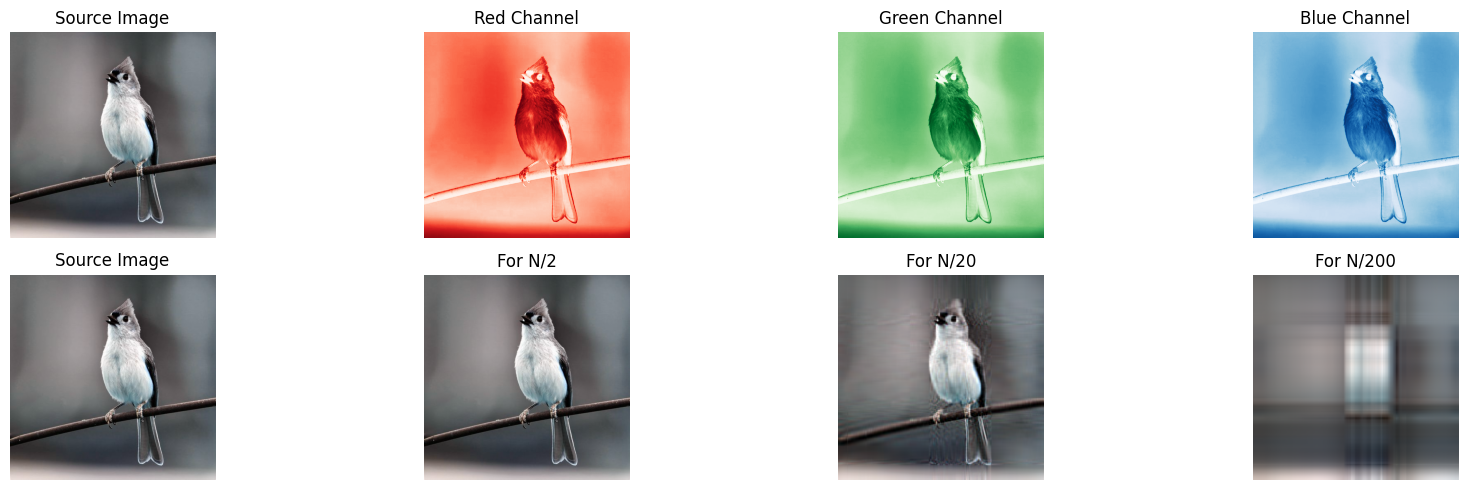

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def get_source_image():
    return cv2.imread('Bird.jpg')


def plot_image(ax, image, title='Image', cmap=None):
    if cmap:
        ax.imshow(image, cmap=cmap)
    else:
        ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')


def rank_k_approximation(N, k, sourceImgRed, sourceImgGreen, sourceImgBlue, Ur, Sr, Vr, Ug, Sg, Vg, Ub, Sb, Vb):
    k1_n = np.zeros_like(sourceImgRed, dtype=float)
    k2_n = np.zeros_like(sourceImgGreen, dtype=float)
    k3_n = np.zeros_like(sourceImgBlue, dtype=float)

    for i in range(N//k):
        k1_n += (Ur[:,i:i+1] @ np.array([[Sr[i]]]) @ Vr[i:i+1,:])
        k2_n += (Ug[:,i:i+1] @ np.array([[Sg[i]]]) @ Vg[i:i+1,:])
        k3_n += (Ub[:,i:i+1] @ np.array([[Sb[i]]]) @ Vb[i:i+1,:])

    img1 = np.uint8(np.clip(np.dstack((k1_n, k2_n, k3_n)), 0, 255))
    return img1


def main():
    SourceImg = get_source_image()
    SourceImg = np.array(SourceImg)

    sourceImgRed = SourceImg[:,:,0]
    sourceImgGreen = SourceImg[:,:,1]
    sourceImgBlue = SourceImg[:,:,2]

    fig, axs = plt.subplots(2, 4, figsize=(18,5))

    plot_image(axs[0,0], SourceImg, title='Source Image')
    plot_image(axs[0,1], sourceImgRed, title='Red Channel', cmap='Reds')
    plot_image(axs[0,2], sourceImgGreen, title='Green Channel', cmap='Greens')
    plot_image(axs[0,3], sourceImgBlue, title='Blue Channel', cmap='Blues')

    # SVD for Red Channel
    Ur, Sr, Vr = np.linalg.svd(sourceImgRed.astype(float))

    # SVD for Green Channel
    Ug, Sg, Vg = np.linalg.svd(sourceImgGreen.astype(float))

    # SVD for Blue Channel
    Ub, Sb, Vb = np.linalg.svd(sourceImgBlue.astype(float))

    # Rank Approximation
    N = SourceImg.shape[1]

    plot_image(axs[1,0], SourceImg, title='Source Image')
    for idx, k in enumerate((2, 20, 200)):
        plot_image(
            axs[1,idx+1],
            rank_k_approximation(N, k, sourceImgRed, sourceImgGreen, sourceImgBlue, Ur, Sr, Vr, Ug, Sg, Vg, Ub, Sb, Vb),
            title=f'For N/{k}'
        )

    plt.tight_layout()
    plt.show()

main()

## Conclusion


In this notebook, we applied Singular Value Decomposition (SVD) for image compression using different rank approximations. By reconstructing images with reduced singular values, we observed the trade-off between image quality and compression.

This exercise demonstrated how SVD can efficiently represent image data using only the most significant components while reducing storage requirements.

## Additional Practice Questions

1.  **Explore the impact of noise on linear regression:** Modify the data generation step in Part A to increase or decrease the amount of random noise (`np.random.randn`). How does this affect the `aHat` coefficients and the SSE of Model 1? Plot the results to visually demonstrate the effect of noise.

2.  **Implement a different error metric:** In Part A, we used Sum of Squared Errors (SSE). Implement and calculate the Mean Absolute Error (MAE) for each of the four models. Does the 'best-fit' model change based on this new metric? Explain your observations.

    *   **Mean Absolute Error (MAE):** $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

3.  **Investigate different image compression ratios:** In Part B, we used `N/2`, `N/20`, and `N/200` for rank approximation. Try different `k` values, such as `N/5`, `N/50`, or even a fixed number like `k=10`. Plot the results and describe how the image quality and perceived compression change with these different values.

4.  **Analyze singular value distribution:** For one of the color channels in Part B (e.g., Red), plot the singular values (`Sr`). What do you observe about their distribution? How does this distribution explain why low-rank approximation works for image compression?

In [ ]:
# Code Here
